In [14]:
# enables the %%R magic, not necessary if you've already done this
%load_ext rpy2.ipython

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt


# Set seed for reproducibility
seed = 27
np.random.seed(seed)

# Load the dataset
drtb_path = "/Users/mraniereneves/Library/CloudStorage/OneDrive-YaleUniversity/Yale/TB/Republic of Moldova data/DATA_tb_moldova_NN.csv"
drtb = pd.read_csv(drtb_path)

# Remove the 'Residence' variable
drtb = drtb.drop('Residence', axis=1)

# Split target and covariates
y = drtb['FLQ_R']
X = drtb.drop('FLQ_R', axis=1)

# Standardize specific features: 'Age', 'Family_size', and 'Family_size18'
features_to_standardize = ['Age', 'Family_size', 'Family_size18']
scaler = StandardScaler()
X[features_to_standardize] = scaler.fit_transform(X[features_to_standardize])


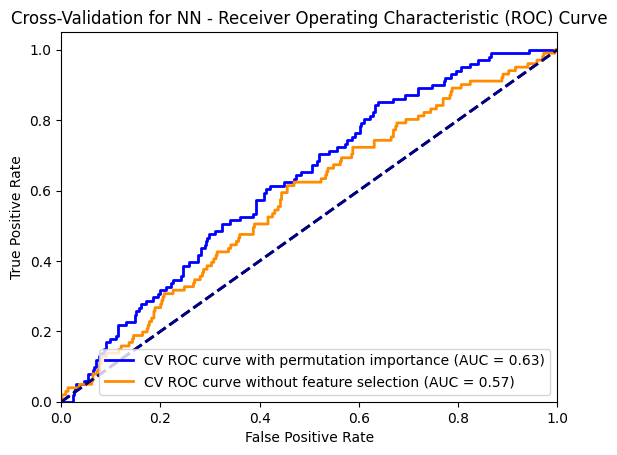


Overall AUROC across 5 folds with permutation importance: 0.63
Overall AUROC on the test set with permutation importance: 0.59

Overall AUROC across 5 folds without feature selection: 0.57
Overall AUROC on the test set without feature selection: 0.59


In [20]:

# Define a neural network model with lbfgs solver, tanh activation, and one hidden layer
model = MLPClassifier(
    hidden_layer_sizes=(X.shape[1] + 2,),
    activation='tanh',
    solver='lbfgs',
    random_state=seed,
    max_iter=10000
)

# Pre-fit the model on the entire dataset
model.fit(X, y)

# Compute permutation importance
perm_importance = permutation_importance(model, X, y, n_repeats=10, random_state=seed)
sorted_feature_indices = np.argsort(perm_importance.importances_mean)[::-1]
num_selected_features = 27  # Adjust this based on your preference
selected_features = X.columns[sorted_feature_indices[:num_selected_features]]

# Perform 5-fold cross-validation and get true labels and predicted probabilities with permutation importance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
y_true_cv_perm = []
y_pred_probs_cv_perm = []

for train, test in cv.split(X, y):
    # Train the model with selected features
    model.fit(X.iloc[train][selected_features], y.iloc[train])

    # Predict probabilities on the test set
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = model.predict_proba(X.iloc[test][selected_features])[:, 1]

    y_true_cv_perm.extend(y_true_fold)
    y_pred_probs_cv_perm.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation with permutation importance
fpr_cv_perm, tpr_cv_perm, _ = roc_curve(y_true_cv_perm, y_pred_probs_cv_perm)
roc_auc_cv_perm = auc(fpr_cv_perm, tpr_cv_perm)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, random_state=seed)

# Train the model on the training set with permutation importance selected features
model.fit(X_train, y_train)

# Evaluate the model on the test set with permutation importance selected features
y_pred_probs_test_perm = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for the test set with permutation importance selected features
fpr_test_perm, tpr_test_perm, _ = roc_curve(y_test, y_pred_probs_test_perm)
roc_auc_test_perm = auc(fpr_test_perm, tpr_test_perm)

# Train the model on the entire dataset without feature selection
model.fit(X, y)

# Perform 5-fold cross-validation and get true labels and predicted probabilities without feature selection
y_true_cv_full = []
y_pred_probs_cv_full = []

for train, test in cv.split(X, y):
    # Train the model without feature selection
    model.fit(X.iloc[train], y.iloc[train])

    # Predict probabilities on the test set
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = model.predict_proba(X.iloc[test])[:, 1]

    y_true_cv_full.extend(y_true_fold)
    y_pred_probs_cv_full.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation without feature selection
fpr_cv_full, tpr_cv_full, _ = roc_curve(y_true_cv_full, y_pred_probs_cv_full)
roc_auc_cv_full = auc(fpr_cv_full, tpr_cv_full)

# Train the model on the training set without feature selection
model.fit(X_train, y_train)

# Evaluate the model on the test set without feature selection
y_pred_probs_test_full = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for the test set without feature selection
fpr_test_full, tpr_test_full, _ = roc_curve(y_test, y_pred_probs_test_full)
roc_auc_test_full = auc(fpr_test_full, tpr_test_full)

# Plot ROC curves side by side
#plt.figure(figsize=(6, 12))

# ROC curve for the test set with permutation importance selected features
#plt.subplot(2, 2, 1)
#plt.plot(fpr_test_perm, tpr_test_perm, color='blue', lw=2, label=f'Test ROC curve with permutation importance (AUC = {roc_auc_test_perm:.2f})')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('Test Set with Permutation Importance - Receiver Operating Characteristic (ROC) Curve')
#plt.legend(loc="lower right")

# ROC curve for the test set without feature selection
#plt.subplot(2, 2, 2)
#plt.plot(fpr_test_full, tpr_test_full, color='darkorange', lw=2, label=f'Test ROC curve without feature selection (AUC = {roc_auc_test_full:.2f})')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('Test Set without Feature Selection - Receiver Operating Characteristic (ROC) Curve')
#plt.legend(loc="lower right")

# ROC curve for cross-validation with permutation importance selected features
#plt.subplot(2, 2, 3)
plt.plot(fpr_cv_perm, tpr_cv_perm, color='blue', lw=2, label=f'CV ROC curve with permutation importance (AUC = {roc_auc_cv_perm:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for NN - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# ROC curve for cross-validation without feature selection
#plt.subplot(2, 2, 4)
plt.plot(fpr_cv_full, tpr_cv_full, color='darkorange', lw=2, label=f'CV ROC curve without feature selection (AUC = {roc_auc_cv_full:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for NN - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

#plt.tight_layout()
plt.show()

# Report overall AUROC
print(f"\nOverall AUROC across 5 folds with permutation importance: {roc_auc_cv_perm:.2f}")
print(f"Overall AUROC on the test set with permutation importance: {roc_auc_test_perm:.2f}")

print(f"\nOverall AUROC across 5 folds without feature selection: {roc_auc_cv_full:.2f}")
print(f"Overall AUROC on the test set without feature selection: {roc_auc_test_full:.2f}")



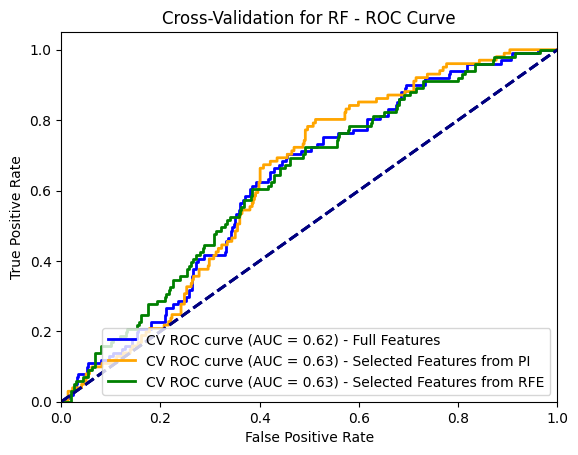


Overall AUROC across 5 folds without feature selection (Random Forest): 0.62
Overall AUROC across 5 folds with selected features from PI (Random Forest): 0.63
Overall AUROC across 5 folds with selected features from RFE (Random Forest): 0.63


In [21]:
# Define a Random Forest model with 100 trees and minimum samples per leaf set to 5
model = RandomForestClassifier(
    n_estimators=100,
    min_samples_leaf=15,
    random_state=7
)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)

# Train the model on the training set without feature selection
model.fit(X_train, y_train)

# Evaluate the model on the test set without feature selection using ROC-AUC
y_pred_probs_test_full = model.predict_proba(X_test)[:, 1]
fpr_test_full, tpr_test_full, _ = roc_curve(y_test, y_pred_probs_test_full)
roc_auc_test_full = auc(fpr_test_full, tpr_test_full)

# Perform 5-fold cross-validation without feature selection and get true labels and predicted probabilities
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
y_true_cv_full = []
y_pred_probs_cv_full = []

for train, test in cv.split(X, y):
    # Train the model without feature selection
    model.fit(X.iloc[train], y.iloc[train])

    # Predict probabilities on the test set without feature selection
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = model.predict_proba(X.iloc[test])[:, 1]

    y_true_cv_full.extend(y_true_fold)
    y_pred_probs_cv_full.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation without feature selection
fpr_cv_full, tpr_cv_full, _ = roc_curve(y_true_cv_full, y_pred_probs_cv_full)
roc_auc_cv_full = auc(fpr_cv_full, tpr_cv_full)

# Compute permutation importance on the entire dataset
perm_importance = permutation_importance(model, X, y, n_repeats=30, random_state=7)
sorted_feature_indices_perm = np.argsort(perm_importance.importances_mean)[::-1]
num_selected_features_perm = 30  # Adjust this based on your preference
selected_features_perm = X.columns[sorted_feature_indices_perm[:num_selected_features_perm]]

# Split the dataset into training and testing sets (80% training, 20% testing) using selected features from PI
X_train_pi, X_test_pi, y_train_pi, y_test_pi = train_test_split(X[selected_features_perm], y, test_size=0.2, random_state=7)

# Train the model on the training set with selected features from PI
model.fit(X_train_pi, y_train_pi)

# Evaluate the model on the test set with the selected features from PI using ROC-AUC
y_pred_probs_test_pi = model.predict_proba(X_test_pi)[:, 1]
fpr_test_pi, tpr_test_pi, _ = roc_curve(y_test_pi, y_pred_probs_test_pi)
roc_auc_test_pi = auc(fpr_test_pi, tpr_test_pi)

# Perform 5-fold cross-validation with selected features from PI and get true labels and predicted probabilities
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
y_true_cv_pi = []
y_pred_probs_cv_pi = []

for train, test in cv.split(X[selected_features_perm], y):
    # Train the model with selected features from PI
    model.fit(X[selected_features_perm].iloc[train], y.iloc[train])

    # Predict probabilities on the test set with selected features from PI
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = model.predict_proba(X[selected_features_perm].iloc[test])[:, 1]

    y_true_cv_pi.extend(y_true_fold)
    y_pred_probs_cv_pi.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation with selected features from PI
fpr_cv_pi, tpr_cv_pi, _ = roc_curve(y_true_cv_pi, y_pred_probs_cv_pi)
roc_auc_cv_pi = auc(fpr_cv_pi, tpr_cv_pi)

# Use Recursive Feature Elimination (RFE) to select features
rfe = RFECV(estimator=RandomForestClassifier(n_estimators=100, min_samples_leaf=5, random_state=7), step=1, cv=StratifiedKFold(5), scoring='roc_auc')
X_rfe = rfe.fit_transform(X, y)

# Split the dataset into training and testing sets (80% training, 20% testing) using selected features from RFE
X_train_rfe, X_test_rfe, y_train_rfe, y_test_rfe = train_test_split(X[X.columns[rfe.support_]], y, test_size=0.2, random_state=7)

# Train the model on the training set with selected features from RFE
model.fit(X_train_rfe, y_train_rfe)

# Evaluate the model on the test set with the selected features from RFE using ROC-AUC
y_pred_probs_test_rfe = model.predict_proba(X_test_rfe)[:, 1]
fpr_test_rfe, tpr_test_rfe, _ = roc_curve(y_test_rfe, y_pred_probs_test_rfe)
roc_auc_test_rfe = auc(fpr_test_rfe, tpr_test_rfe)

# Perform 5-fold cross-validation with selected features from RFE and get true labels and predicted probabilities
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
y_true_cv_rfe = []
y_pred_probs_cv_rfe = []

for train, test in cv.split(X[X.columns[rfe.support_]], y):
    # Train the model with selected features from RFE
    model.fit(X[X.columns[rfe.support_]].iloc[train], y.iloc[train])

    # Predict probabilities on the test set with selected features from RFE
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = model.predict_proba(X[X.columns[rfe.support_]].iloc[test])[:, 1]

    y_true_cv_rfe.extend(y_true_fold)
    y_pred_probs_cv_rfe.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation with selected features from RFE
fpr_cv_rfe, tpr_cv_rfe, _ = roc_curve(y_true_cv_rfe, y_pred_probs_cv_rfe)
roc_auc_cv_rfe = auc(fpr_cv_rfe, tpr_cv_rfe)

# Plot ROC curves side by side
#plt.figure(figsize=(16, 12))

# ROC curve for the test set without feature selection
#plt.subplot(2, 2, 1)
#plt.plot(fpr_test_full, tpr_test_full, color='blue', lw=2, label=f'Test ROC curve (AUC = {roc_auc_test_full:.2f}) - Full Features')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('Test Set - ROC Curve')
#plt.legend(loc="lower right")

# ROC curve for cross-validation without feature selection
#plt.subplot(2, 2, 2)
plt.plot(fpr_cv_full, tpr_cv_full, color='blue', lw=2, label=f'CV ROC curve (AUC = {roc_auc_cv_full:.2f}) - Full Features')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for RF - ROC Curve')
plt.legend(loc="lower right")

# ROC curve for the test set with selected features from PI
#plt.subplot(2, 2, 3)
#plt.plot(fpr_test_pi, tpr_test_pi, color='orange', lw=2, label=f'Test ROC curve (AUC = {roc_auc_test_pi:.2f}) - Selected Features from PI')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('Test Set - ROC Curve')
#plt.legend(loc="lower right")

# ROC curve for cross-validation with selected features from PI
#plt.subplot(2, 2, 4)
plt.plot(fpr_cv_pi, tpr_cv_pi, color='orange', lw=2, label=f'CV ROC curve (AUC = {roc_auc_cv_pi:.2f}) - Selected Features from PI')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for RF - ROC Curve')
plt.legend(loc="lower right")

#plt.tight_layout()
#plt.show()

# Plot ROC curves side by side for RFE
#plt.figure(figsize=(16, 6))

# ROC curve for the test set with selected features from RFE
#plt.subplot(1, 2, 1)
#plt.plot(fpr_test_rfe, tpr_test_rfe, color='green', lw=2, label=f'Test ROC curve (AUC = {roc_auc_test_rfe:.2f}) - Selected Features from RFE')
#plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
#plt.xlim([0.0, 1.0])
#plt.ylim([0.0, 1.05])
#plt.xlabel('False Positive Rate')
#plt.ylabel('True Positive Rate')
#plt.title('Test Set - ROC Curve')
#plt.legend(loc="lower right")

# ROC curve for cross-validation with selected features from RFE
#plt.subplot(1, 2, 2)
plt.plot(fpr_cv_rfe, tpr_cv_rfe, color='green', lw=2, label=f'CV ROC curve (AUC = {roc_auc_cv_rfe:.2f}) - Selected Features from RFE')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for RF - ROC Curve')
plt.legend(loc="lower right")

#plt.tight_layout()
plt.show()

# Report overall AUROC
print(f"\nOverall AUROC across 5 folds without feature selection (Random Forest): {roc_auc_cv_full:.2f}")
print(f"Overall AUROC across 5 folds with selected features from PI (Random Forest): {roc_auc_cv_pi:.2f}")
print(f"Overall AUROC across 5 folds with selected features from RFE (Random Forest): {roc_auc_cv_rfe:.2f}")


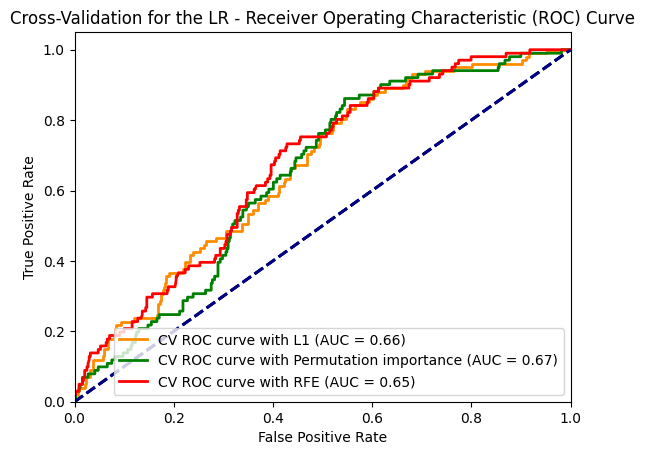

In [17]:
# Define a logistic regression model with L1 regularization
logreg_model_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=seed)

# Perform 5-fold cross-validation and get true labels and predicted probabilities with permutation importance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
y_true_cv_logreg_l1 = []
y_pred_probs_cv_logreg_l1 = []

for train, test in cv.split(X, y):
    # Train the model with selected features
    logreg_model_l1.fit(X.iloc[train], y.iloc[train])

    # Predict probabilities on the test set
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = logreg_model_l1.predict_proba(X.iloc[test])[:, 1]

    y_true_cv_logreg_l1.extend(y_true_fold)
    y_pred_probs_cv_logreg_l1.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation with permutation importance selected features
fpr_cv_logreg_l1, tpr_cv_logreg_l1, _ = roc_curve(y_true_cv_logreg_l1, y_pred_probs_cv_logreg_l1)
roc_auc_cv_logreg_l1 = auc(fpr_cv_logreg_l1, tpr_cv_logreg_l1)

# Specify the model without regularization
logreg_model = LogisticRegression()

# Pre-fit the model on the entire dataset
logreg_model.fit(X, y)

# Compute permutation importance
perm_importance = permutation_importance(logreg_model, X, y, n_repeats=10, random_state=seed)
sorted_feature_indices = np.argsort(perm_importance.importances_mean)[::-1]
num_selected_features = 27  # Adjust this based on your preference
selected_features_pi = X.columns[sorted_feature_indices[:num_selected_features]]

# Perform 5-fold cross-validation and get true labels and predicted probabilities
y_true_cv_logreg_pi = []
y_pred_probs_cv_logreg_pi = []

for train, test in cv.split(X, y):
    # Train the model with selected features
    logreg_model.fit(X.iloc[train][selected_features_pi], y.iloc[train])

    # Predict probabilities on the test set
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = logreg_model.predict_proba(X.iloc[test][selected_features_pi])[:, 1]

    y_true_cv_logreg_pi.extend(y_true_fold)
    y_pred_probs_cv_logreg_pi.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation
fpr_cv_logreg_pi, tpr_cv_logreg_pi, _ = roc_curve(y_true_cv_logreg_pi, y_pred_probs_cv_logreg_pi)
roc_auc_cv_logreg_pi = auc(fpr_cv_logreg_pi, tpr_cv_logreg_pi)

# Initialize RFE with the logistic regression model
rfe = RFE(logreg_model, n_features_to_select=num_selected_features)  

# Fit RFE on the entire training data
rfe.fit(X, y)

# Get selected features
selected_features_rfe = X.columns[rfe.support_]

# Lists to store results for each fold
y_true_cv_logreg_rfe = []
y_pred_probs_cv_logreg_rfe = []

# Perform 5-fold cross-validation
for train, test in cv.split(X, y):
    # Train logistic regression model on the selected features
    logreg_model.fit(X.iloc[train][selected_features_rfe], y.iloc[train])

    # Predict probabilities on the test set
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = logreg_model.predict_proba(X.iloc[test][selected_features_rfe])[:, 1]

    y_true_cv_logreg_rfe.extend(y_true_fold)
    y_pred_probs_cv_logreg_rfe.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation with RFE-selected features
fpr_cv_logreg_rfe, tpr_cv_logreg_rfe, _ = roc_curve(y_true_cv_logreg_rfe, y_pred_probs_cv_logreg_rfe)
roc_auc_cv_logreg_rfe = auc(fpr_cv_logreg_rfe, tpr_cv_logreg_rfe)


# ROC curve for cross-validation with logistic regression and L1 selected features
#plt.subplot(3, 2, 5)
plt.plot(fpr_cv_logreg_l1, tpr_cv_logreg_l1, color='darkorange', lw=2, label=f'CV ROC curve with L1 (AUC = {roc_auc_cv_logreg_l1:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for the LR - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.plot(fpr_cv_logreg_pi, tpr_cv_logreg_pi, color='green', lw=2, label=f'CV ROC curve with Permutation importance (AUC = {roc_auc_cv_logreg_rfe:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for the LR - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.plot(fpr_cv_logreg_rfe, tpr_cv_logreg_rfe, color='red', lw=2, label=f'CV ROC curve with RFE (AUC = {roc_auc_cv_logreg_pi:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation for the LR - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


Setting levels: control = 0, case = 1
Setting direction: controls > cases


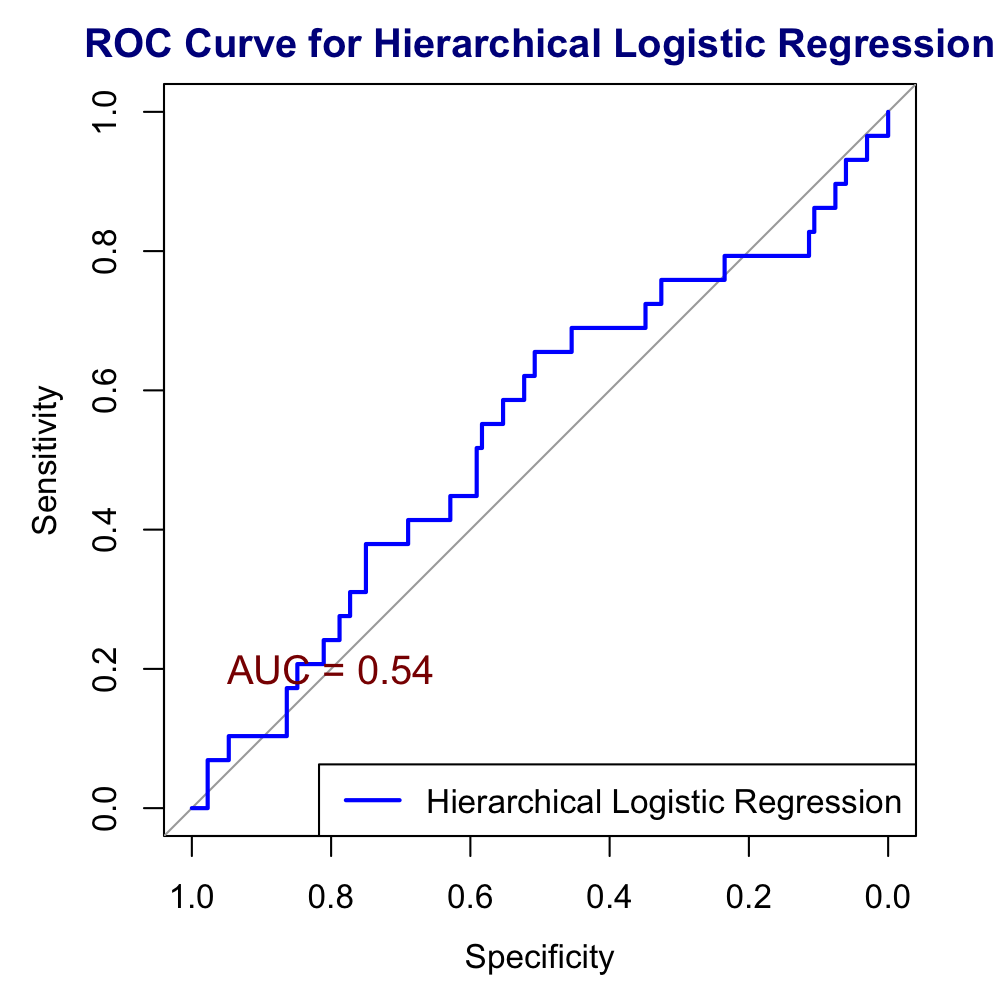

In [23]:
%%R -w 5 -h 5 --units in -r 200
library(glmnet)
library(dplyr)
library(pROC)
library(ROCR)
library(caret)
#Using parsnip
library(multilevelmod)
library(tidymodels)

set.seed(107)

# Load the new dataset
data_path <- "/Users/mraniereneves/Library/CloudStorage/OneDrive-YaleUniversity/Yale/TB/Republic of Moldova data/DATA_tb_moldova_HM.csv"
moldova_data <- read.csv(data_path)

#removing all ocupation and urban missing
moldova_data = moldova_data %>%
  filter(Occupation_missing != 1, Urban_missing != 1)


################
# HM modelling #
################


# Split the data into training and testing sets (80% training, 20% testing)
set_split <- createDataPartition(moldova_data$FLQ_R, p = 0.7, list = FALSE)
train_data <- moldova_data[set_split, ]
test_data <- moldova_data[-set_split, ]

#Hierarchical model
start.time <- Sys.time()

test = logistic_reg() %>% 
  set_engine("stan_glmer", iter = 10000, warmup = 1000) %>% 
  fit(as.factor(FLQ_R) ~  Age+
        Family_size+
        #Family_size18+
        Sex_2+
        Occupation_2+
        Occupation_3+
        Occupation_4+
        Occupation_5+
        #Occupation_missing+
        Education_2+
        Education_3+
        Education_4+
        Education_5+
        Education_missing+
        Living_condition_1+
        Living_condition_missing+
        Outside_moldova_1+
        Outside_moldova_missing+
        Urban_1+
        #Urban_missing+
        Homeless_1+
        Homeless_missing+
        Money_assistance_1+
        Money_assistance_missing+
        Incarceration_1+
        Incarceration_missing+
        TB_main_loc_extra+
        TB_type_2+
        TB_type_3+
        TB_type_4+
        TB_type_6+
        (1 | Residence)
      ,
      data = train_data, mean_PPD = FALSE, init = "random")
end.time <- Sys.time()

# Predict probabilities on the testing set
y_prob <- predict(test, new_data = test_data, type = "prob") %>%
  pull(.pred_1)

# Create a ROC curve for the testing set
roc_curve <- roc(response = test_data$FLQ_R, predictor = y_prob)

# Plot the ROC curve
plot(roc_curve, col = "blue", main = "ROC Curve for Hierarchical Logistic Regression", col.main = "darkblue", lwd = 2)

# Add AUC to the plot
text(0.8, 0.2, paste("AUC =", round(auc(roc_curve), 2)), col = "darkred", cex = 1.2)

# Add legend
legend("bottomright", legend = "Hierarchical Logistic Regression", col = "blue", lwd = 2)
